<a href="https://colab.research.google.com/github/ratnesh44/cnn/blob/main/24it3044_CNN_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK - 01

### Problem - 01

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import random

In [2]:
print("Version of tensorflow is : ",tf.__version__)
print("Version of numpy is : ",np.__version__)
print("Version of pandas is : ",pd.__version__)
print("Version of matplotlib is :",matplotlib.__version__)
gpuCheck = tf.config.list_physical_devices('GPU')
if gpuCheck:
    print("GPU is available")
else:
    print("GPU is not available")

    # Gpu perform parallel processing on multiple cores which increases speed of deep learning tasks while cpu perform sequential processing on limited cores hence cpu are slower as compared to gpus.
    # Deep learning have large matrix multiplication so gpu are preferred.

Version of tensorflow is :  2.19.0
Version of numpy is :  2.0.2
Version of pandas is :  2.2.2
Version of matplotlib is : 3.10.0
GPU is available


In [3]:
# setting all random seeds to 42
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
# we are setting random seeds to 42 to ensure reproducibility of results
# np.random.seed(42) controls randomness in numpy and makes sure it generates same sequence of random numbers everytime.
# tf.random.set_seed(42) it ensures tensorflow produces same random results evrytime
# random.seed(42) so random results are reproducible


### Problem - 02

In [4]:
from tensorflow.keras.datasets import mnist, cifar10

# Load MNIST
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Load CIFAR-10
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [5]:
# printing shape

print("MNIST x_train shape:", x_train_mnist.shape)
print("MNIST y_train shape:", y_train_mnist.shape)
print("MNIST x_test shape:", x_test_mnist.shape)
print("MNIST y_test shape:", y_test_mnist.shape)
print("----------------------------------------------------")
print("CIFAR-10 x_train shape:", x_train_cifar.shape)
print("CIFAR-10 y_train shape:", y_train_cifar.shape)
print("CIFAR-10 x_test shape:", x_test_cifar.shape)
print("CIFAR-10 y_test shape:", y_test_cifar.shape)

MNIST x_train shape: (60000, 28, 28)
MNIST y_train shape: (60000,)
MNIST x_test shape: (10000, 28, 28)
MNIST y_test shape: (10000,)
----------------------------------------------------
CIFAR-10 x_train shape: (50000, 32, 32, 3)
CIFAR-10 y_train shape: (50000, 1)
CIFAR-10 x_test shape: (10000, 32, 32, 3)
CIFAR-10 y_test shape: (10000, 1)


In [6]:
# printing datatype and value range
print("MNIST Train dtype:", x_train_mnist.dtype)
print("MNIST Train range:", x_train_mnist.min(), x_train_mnist.max())
print("MNIST Test dtype:", x_test_mnist.dtype)
print("MNIST Test range:", x_test_mnist.min(), x_test_mnist.max())

print("----------------------------------------------------")

print("CIFAR-10 Train dtype:", x_train_cifar.dtype)
print("CIFAR-10 Train range:", x_train_cifar.min(), x_train_cifar.max())
print("CIFAR-10 Test dtype:", x_test_cifar.dtype)
print("CIFAR-10 Test range:", x_test_cifar.min(), x_test_cifar.max())

MNIST Train dtype: uint8
MNIST Train range: 0 255
MNIST Test dtype: uint8
MNIST Test range: 0 255
----------------------------------------------------
CIFAR-10 Train dtype: uint8
CIFAR-10 Train range: 0 255
CIFAR-10 Test dtype: uint8
CIFAR-10 Test range: 0 255


In [7]:
# samples per class
unique, counts = np.unique(y_train_mnist, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} samples")

# The number of samples per class in the MNIST training dataset ranges approximately from 5400 to 6700.
# Although the counts are not exactly equal, the variation is small across all classes.
# Therefore, the dataset is considered balanced as each class has a similar number of samples.

Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


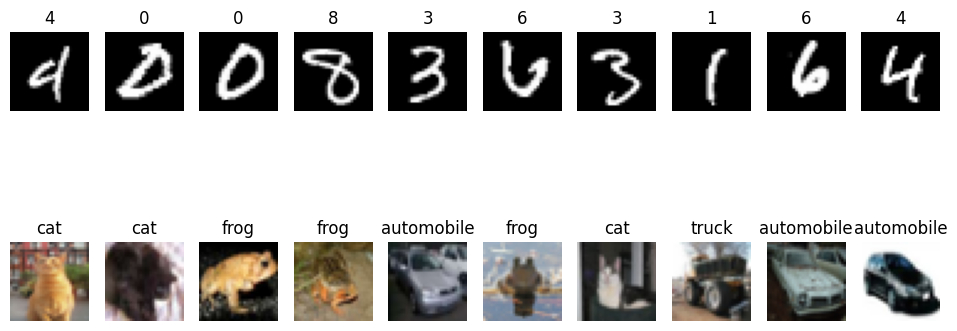

In [8]:
# CIFAR-10 class names
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12,5))

# MNIST (top row)
for i in range(10):
    idx = np.random.randint(0, 60000)
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train_mnist[idx], cmap='gray')
    plt.title(y_train_mnist[idx])
    plt.axis('off')

# CIFAR-10 (bottom row)
for i in range(10):
    idx = np.random.randint(0, 50000)
    plt.subplot(2, 10, 10+i+1)
    plt.imshow(x_train_cifar[idx])
    plt.title(cifar_classes[y_train_cifar[idx][0]])
    plt.axis('off')

plt.savefig("dataset_samples.png")
plt.show()

The MNIST dataset consists of grayscale images with shape (60000, 28, 28) for training and (10000, 28, 28) for testing, along with corresponding label arrays of shape (60000,) and (10000,).

The CIFAR-10 dataset consists of color images with shape (50000, 32, 32, 3) for training and (10000, 32, 32, 3) for testing, with label arrays of shape (50000, 1) and (10000, 1).

For both datasets, the pixel values are of type uint8 and range from 0 to 255 before preprocessing.



### Problem - 03

In [9]:
def preprocess(images, labels, is_mnist=False):
    print("BEFORE:")
    print("Shape:", images.shape)
    print("Dtype:", images.dtype)
    print("Range:", images.min(), "-", images.max())

    images = images.astype('float32') / 255.0
    #(b)Reshape MNIST
    if is_mnist:
        images = images.reshape(-1, 28, 28, 1)
    #(c)One-hot encode
    labels = tf.keras.utils.to_categorical(labels, 10)
    print("\nAFTER:")
    print("Shape:", images.shape)
    print("Dtype:", images.dtype)
    print("Range:", images.min(), "-", images.max())
    print("Label shape:", labels.shape)
    print("\n")
    return images, labels
# Apply preprocessing
print("MNIST:")
x_train_mnist_p, y_train_mnist_p = preprocess(x_train_mnist, y_train_mnist, True)
x_test_mnist_p, y_test_mnist_p = preprocess(x_test_mnist, y_test_mnist, True)
print("CIFAR:")
x_train_cifar_p, y_train_cifar_p = preprocess(x_train_cifar, y_train_cifar)
x_test_cifar_p, y_test_cifar_p = preprocess(x_test_cifar, y_test_cifar)

MNIST:
BEFORE:
Shape: (60000, 28, 28)
Dtype: uint8
Range: 0 - 255

AFTER:
Shape: (60000, 28, 28, 1)
Dtype: float32
Range: 0.0 - 1.0
Label shape: (60000, 10)


BEFORE:
Shape: (10000, 28, 28)
Dtype: uint8
Range: 0 - 255

AFTER:
Shape: (10000, 28, 28, 1)
Dtype: float32
Range: 0.0 - 1.0
Label shape: (10000, 10)


CIFAR:
BEFORE:
Shape: (50000, 32, 32, 3)
Dtype: uint8
Range: 0 - 255

AFTER:
Shape: (50000, 32, 32, 3)
Dtype: float32
Range: 0.0 - 1.0
Label shape: (50000, 10)


BEFORE:
Shape: (10000, 32, 32, 3)
Dtype: uint8
Range: 0 - 255

AFTER:
Shape: (10000, 32, 32, 3)
Dtype: float32
Range: 0.0 - 1.0
Label shape: (10000, 10)




### Problem - 04

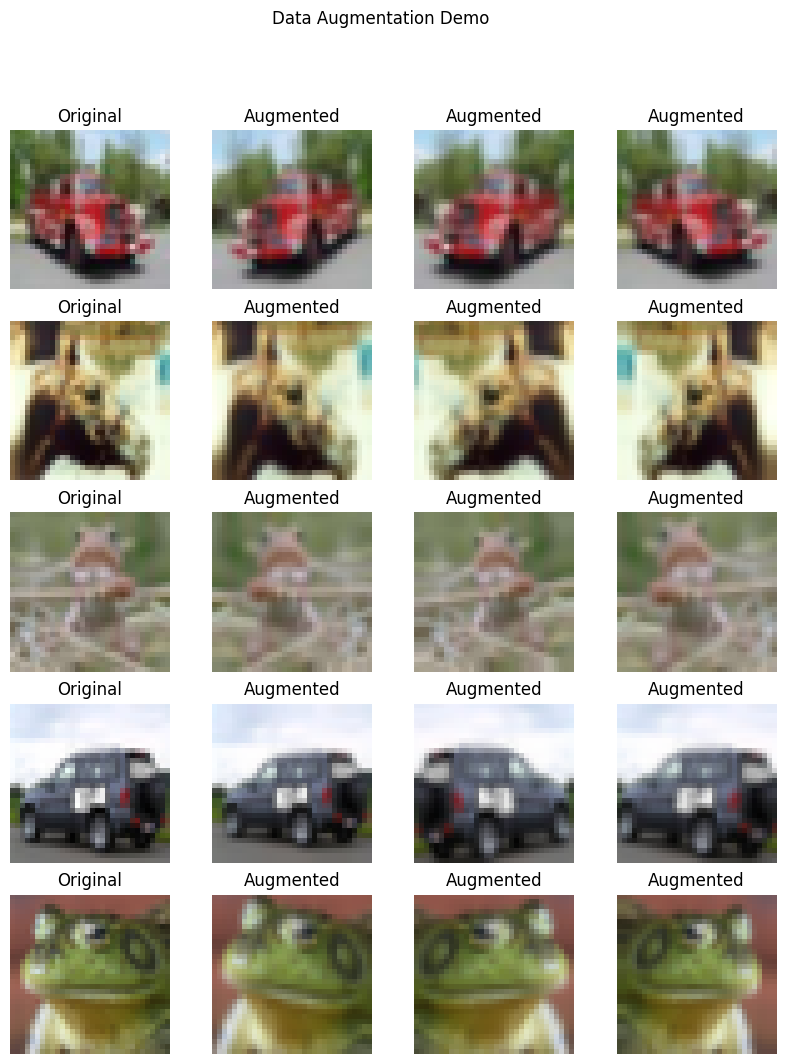

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Augmentation pipeline
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)
# Plot augmented images
plt.figure(figsize=(10, 12))
for i in range(5):
    idx = np.random.randint(0, len(x_train_cifar))
    original = x_train_cifar[idx]
    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis('off')

    original = np.expand_dims(original, 0)
    aug_iter = datagen.flow(original, batch_size=1)

    for j in range(3):
        aug_img = next(aug_iter)[0].astype('uint8')
        plt.subplot(5, 4, i*4 + j + 2)
        plt.imshow(aug_img)
        plt.title("Augmented")
        plt.axis('off')

plt.suptitle("Data Augmentation Demo")
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set because it increases data diversity and helps the model learn better, improving generalization.

Validation and test sets must remain unchanged so that they represent real, unseen data. If augmentation is applied to them, it would alter the original data distribution and lead to biased or unreliable evaluation results. Therefore, augmentation is used only during training and not during validation or testing.

---



In [11]:
# ans -01

In a tensor of shape (N, H, W, C), the channel dimension (C) represents the number of feature channels in each image.

For a greyscale image, C = 1 because each pixel has only one intensity value representing brightness.

For an RGB image, C = 3 because each pixel is composed of three values corresponding to the Red, Green, and Blue color channels.

Thus, the channel dimension defines how many values are used to represent each pixel in the image.

---



In [12]:
# ans -02

For very large images like 1024×1024, loading the entire dataset into memory can cause memory issues. To handle this, the following strategies can be used:

1. Data Generators / Batch Loading:
Instead of loading the entire dataset at once, images are loaded in small batches during training. This reduces memory usage because only a few images are kept in memory at any given time.

2. Image Resizing / Downsampling:
Images can be resized to smaller dimensions (e.g., 256×256) before training. This reduces the number of pixels and hence the memory required for storing and processing the images.

---



In [13]:
# ans -03

Using test set statistics for normalization causes data leakage.
The test set is meant to represent unseen data, and using its statistics during preprocessing indirectly exposes information about it to the model. The test set should
be normalized using the training set mean and standard deviation to ensure fair evaluation.

---



# TASK -0 2

### Problem - 01

In [14]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    kern_h, kern_w = kernel.shape

    out_h = (img_h - kern_h) // stride + 1
    out_w = (img_w - kern_w) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(0, out_h):
        for j in range(0, out_w):
            curr_y = i * stride
            curr_x = j * stride
            patch = image[curr_y:curr_y+kern_h, curr_x:curr_x+kern_w]

            output[i, j] = np.sum(patch * kernel)

    return output

test_image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
])

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

output_map = conv2d(test_image, sobel_x, stride=1, padding=0)

print("Numerical Output:")
print(output_map)
print(f"\nOutput Shape: {output_map.shape}")

Numerical Output:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output Shape: (3, 3)


In [15]:
# verification
# Output size formula:
# (N - F + 2P)/S + 1

# = (5 - 3 + 0)/1 + 1
# = 3

# So output shape = (3,3)

The output feature map is:

[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output Shape: (3, 3)

### Problem - 02

## Output Size Calculations

### Formula
Output size = (N - F + 2P) / S + 1

---

### (a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1

N = 28, F = 5, P = 0, S = 1  

Output = (28 - 5 + 2×0)/1 + 1  
       = 23 + 1  
       = 24  

**Output size = 24 × 24**

---

### (b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1

N = 28, F = 3, P = 1, S = 1  

Output = (28 - 3 + 2×1)/1 + 1  
       = 27 + 1  
       = 28  

**Output size = 28 × 28**

---

### (c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2

N = 32, F = 3, P = 0, S = 2  

Output = (32 - 3 + 0)/2 + 1  
       = 29/2 + 1  
       = 14.5 + 1  
       = 15.5  

Taking floor value:  

**Output size = 15 × 15**

---

### (d) Two Consecutive Conv2D Layers

#### First Layer: K=3, P=1, S=1 on 32×32

Output1 = (32 - 3 + 2×1)/1 + 1  
        = 31 + 1  
        = 32  

**Output1 = 32 × 32**

#### Second Layer: K=3, P=0, S=1

Output2 = (32 - 3 + 0)/1 + 1  
        = 29 + 1  
        = 30  

**Final Output = 30 × 30**

### Problem - 03

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lenet():
  model = tf.keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(6, (5,5), activation='tanh'),
    layers.AveragePooling2D((2,2)),

    layers.Conv2D(16, (5,5), activation='tanh'),
    layers.AveragePooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
  ])
  return model

model = build_lenet()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

For the first Conv2D layer, the number of parameters is calculated using the formula:

(K × K × C_in + 1) × C_out

Where:
- K = kernel size (5)
- C_in = number of input channels (1 for grayscale image)
- C_out = number of filters (6)
- +1 represents the bias term for each filter

#### Calculation:

= (5 × 5 × 1 + 1) × 6  
= (25 + 1) × 6  
= 26 × 6  
= 156  

#### Explanation:

Each filter has (5×5×1 = 25) weights and 1 bias, so total 26 parameters per filter.  
Since there are 6 filters, total parameters = 26 × 6 = 156.

(C)
In LeNet-5, **Average Pooling** was used because early CNNs focused on smooth feature extraction and noise reduction.

- Average pooling computes the **mean value**, which:
  - Preserves background information  
  - Produces smoother feature maps  

In modern CNNs, **MaxPooling** is more commonly used because it:

- Captures the **most important features** (strong activations)  
- Improves feature detection  
- Provides better performance in deep networks  

### Problem - 04

## Custom CNN Architecture (CIFAR-10)

### ASCII Diagram

Input (32×32×3)
      │
Conv(64, 3×3, same) → BatchNorm → ReLU → MaxPool(2×2)
      │
Conv(128, 3×3, same) → BatchNorm → ReLU → MaxPool(2×2)
      │
Conv(256, 3×3, same) → BatchNorm → ReLU → MaxPool(2×2)
      │
GlobalAveragePooling
      │
Dense(256) → ReLU → Dropout(0.5)
      │
Dense(10, Softmax)

---

### Design Rationale

This CNN uses three convolutional blocks with increasing filter sizes (64, 128, 256) to capture hierarchical features from simple edges to complex patterns. Batch Normalization stabilizes training and improves convergence, while ReLU introduces non-linearity. MaxPooling reduces spatial dimensions and computational cost. Global Average Pooling reduces the number of parameters and helps prevent overfitting, and Dropout in the classifier head further improves generalization. The overall architecture maintains a parameter count within the desired range, ensuring a balance between model capacity and generalization.

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

def customCNN():
    model = tf.keras.Sequential([
        layers.Input(shape=(32,32,3)),

        # Conv Block 1
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 2
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3
        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2,2)),

        # GAP
        layers.GlobalAveragePooling2D(),

        # Dense Head (fixed 👇)
        layers.Dense(256, activation='relu'),  # was 512 → now 256
        layers.Dropout(0.5),

        layers.Dense(10, activation='softmax')
    ])
    return model

model = customCNN()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,970 (1.68 MB)

 Trainable params: 440,074 (1.68 MB)

 Non-trainable params: 896 (3.50 KB)

In [18]:
#ans - 01

### Parameter Efficiency:

#### Case 1: Single 5×5 Conv Layer

Formula:
(K × K × C_in + 1) × C_out

= (5 × 5 × C + 1) × C  
= (25C + 1) × C  
≈ 25C² + C  

---

#### Case 2: Two Stacked 3×3 Conv Layers

First Layer:
= (3 × 3 × C + 1) × C  
= (9C + 1) × C  
≈ 9C² + C  

Second Layer:
= (3 × 3 × C + 1) × C  
= (9C + 1) × C  
≈ 9C² + C  

Total:
≈ (9C² + C) + (9C² + C)  
= 18C² + 2C  

---

#### Comparison

Single 5×5 Conv:
≈ 25C² + C  

Two 3×3 Conv:
≈ 18C² + 2C  

 Since 18C² < 25C², two 3×3 layers use fewer parameters.

---

#### Conclusion

Two stacked 3×3 convolution layers are more parameter-efficient than a single 5×5 convolution layer.

---

#### Additional Advantages of 3×3 Layers

- Introduce more non-linearity (two activation layers instead of one)
- Better feature representation due to deeper architecture
- Lower computational cost
- Commonly used in modern CNNs (e.g., VGG)

In [19]:
# ans - 02

### Role of Batch Normalisation

Batch Normalisation normalizes the activations of each layer by adjusting and scaling them to have a stable mean and variance. This reduces internal covariate shift, making training faster and more stable.

---

### Placement in Layer Stack

Batch Normalisation is typically placed **after the convolution layer and before the activation function**:

Conv → BatchNorm → ReLU

#### Why?

Normalizing the output before applying the non-linearity ensures that the activation function receives well-scaled inputs, improving gradient flow and learning efficiency.

---

### Empirical Benefits

- **Faster convergence:** Allows the network to train faster and reduces the number of epochs required.
- **Improved stability:** Reduces sensitivity to weight initialization and learning rate.
- **Regularization effect:** Acts as a slight regularizer, helping to reduce overfitting.

In [20]:
#ans - 3

Global Average Pooling (GAP) reduces each feature map to a single value by taking the average of all its spatial values.

For an input of shape (H × W × C), it converts it to (1 × 1 × C), i.e., one value per channel. Geometrically, it summarizes the entire spatial information of each feature map into a single representative value.

If GAP is replaced with Flatten, the feature maps are converted into a long vector of size (H × W × C), preserving all spatial information. This significantly increases the number of parameters in the Dense layers, as the input size becomes much larger, and may lead to overfitting.

In comparison, GAP results in fewer parameters and better generalization but loses detailed spatial information, whereas Flatten retains spatial details but increases parameter count and the risk of overfitting.

# TASK - 3

### Problem - 01

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7777 - loss: 0.8778 - val_accuracy: 0.9065 - val_loss: 0.3787
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8935 - loss: 0.3865 - val_accuracy: 0.9268 - val_loss: 0.2793
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9114 - loss: 0.3127 - val_accuracy: 0.9375 - val_loss: 0.2336
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9232 - loss: 0.2676 - val_accuracy: 0.9468 - val_loss: 0.2016
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9325 - loss: 0.2329 - val_accuracy: 0.9520 - val_loss: 0.1765
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9406 - loss: 0.2044 - val_accuracy: 0.9603 - val_loss: 0.1559
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9478 - loss: 0.1805 - val_accuracy: 0.9647 - val_loss: 0.1391
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9539 - loss: 0.1606 - val_accuracy: 0

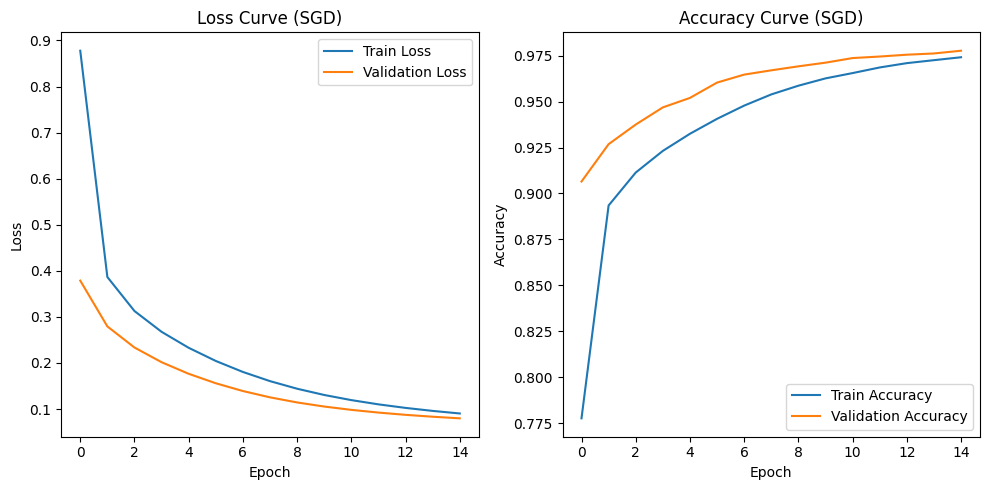

In [21]:
# Build model
model = build_lenet()

# Compile
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train_mnist_p, y_train_mnist_p,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test_mnist_p, y_test_mnist_p)

print("Final Test Accuracy:", test_acc)

import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve (SGD)")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve (SGD)")
plt.legend()

plt.tight_layout()
plt.savefig("lenet_sgd_curves.png")
plt.show()

No clear overfitting is observed within 15 epochs, as validation loss continues to decrease along with training loss.

---
Final Test Accuracy: 0.9739000201225281


### Problem - 02

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7346 - loss: 0.9769 - val_accuracy: 0.8998 - val_loss: 0.3970
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8862 - loss: 0.4040 - val_accuracy: 0.9223 - val_loss: 0.2855
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9067 - loss: 0.3241 - val_accuracy: 0.9363 - val_loss: 0.2376
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9193 - loss: 0.2787 - val_accuracy: 0.9455 - val_loss: 0.2056
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9283 - loss: 0.2452 - val_accuracy: 0.9507 - val_loss: 0.1811
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9358 - loss: 0.2181 - val_accuracy: 0.9567 - val_loss: 0.1613
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9424 - loss: 0.1954 - val_accuracy: 0.9617 - val_loss: 0.1448
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9480 - loss: 0.1761 - val_accuracy: 0.

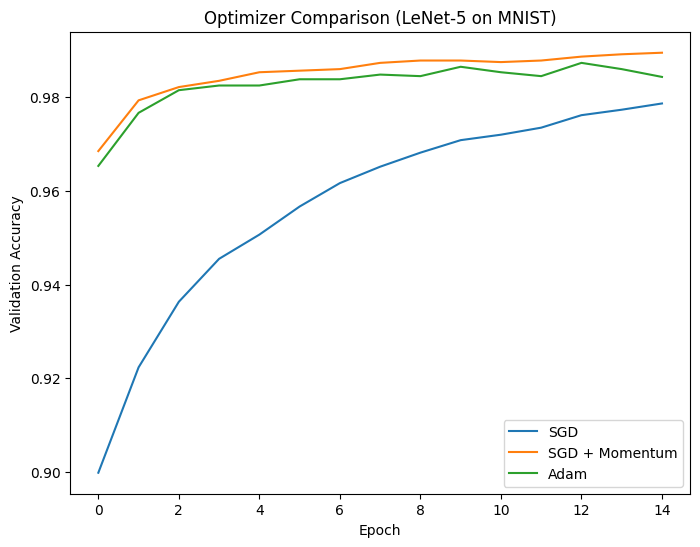

In [22]:
def train_model(optimizer):
    model = build_lenet()
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_mnist_p, y_train_mnist_p,
        epochs=15,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )
    return history

#SGD
hist_sgd = train_model(tf.keras.optimizers.SGD(learning_rate=0.01))

#SGD+Momentum
hist_mom = train_model(tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9))

#Adam
hist_adam = train_model(tf.keras.optimizers.Adam(learning_rate=0.001))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(hist_sgd.history['val_accuracy'], label='SGD')
plt.plot(hist_mom.history['val_accuracy'], label='SGD + Momentum')
plt.plot(hist_adam.history['val_accuracy'], label='Adam')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison (LeNet-5 on MNIST)")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

SGD with momentum converged the fastest, reaching high validation accuracy within the first few epochs.

In terms of final accuracy, SGD with momentum achieved the highest validation accuracy, closely followed by Adam, while plain SGD performed the worst.

### Problem - 03

In [23]:
import pandas as pd
import tensorflow as tf

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = []

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nTraining with LR={lr}, Batch Size={bs}")

        model = customCNN()

        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train_cifar_p, y_train_cifar_p,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=1
        )

        final_val_acc = history.history['val_accuracy'][-1]

        results.append({
            "Learning Rate": lr,
            "Batch Size": bs,
            "Val Accuracy": final_val_acc
        })

df = pd.DataFrame(results)

table = df.pivot(index="Learning Rate", columns="Batch Size", values="Val Accuracy")

print("\nFinal 3×2 Results Table:")
print(table)


Training with LR=0.1, Batch Size=32
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.3779 - loss: 1.6639 - val_accuracy: 0.2444 - val_loss: 3.3019
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5027 - loss: 1.3563 - val_accuracy: 0.3316 - val_loss: 2.3816
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5676 - loss: 1.2020 - val_accuracy: 0.3366 - val_loss: 2.5146
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6122 - loss: 1.0902 - val_accuracy: 0.5716 - val_loss: 1.2641
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6454 - loss: 0.9967 - val_accuracy: 0.3358 - val_loss: 2.9752
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6770 - loss: 0.9164 - val_accuracy: 0.5738 - val_loss: 1.3248
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7049 - loss: 0.8399 - val_accuracy: 0.5286 - val_loss: 1.6168
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/ste

**Best Hyperparameter Combination:**

- Learning Rate: **0.100**
- Batch Size: **32**
- Accuracy: **0.7376**

### Problem - 04


Training: No Regularisation
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.4963 - loss: 1.4114 - val_accuracy: 0.6060 - val_loss: 1.1216
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6391 - loss: 1.0359 - val_accuracy: 0.6782 - val_loss: 0.9437
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6892 - loss: 0.8868 - val_accuracy: 0.6970 - val_loss: 0.8786
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7283 - loss: 0.7746 - val_accuracy: 0.7054 - val_loss: 0.8542
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7647 - loss: 0.6760 - val_accuracy: 0.7196 - val_loss: 0.8540
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7949 - loss: 0.5895 - val_accuracy: 0.7188 - val_loss: 0.8812
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8267 - loss: 0.5029 - val_accuracy: 0.6998 - val_loss: 0.9687
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8538 - lo

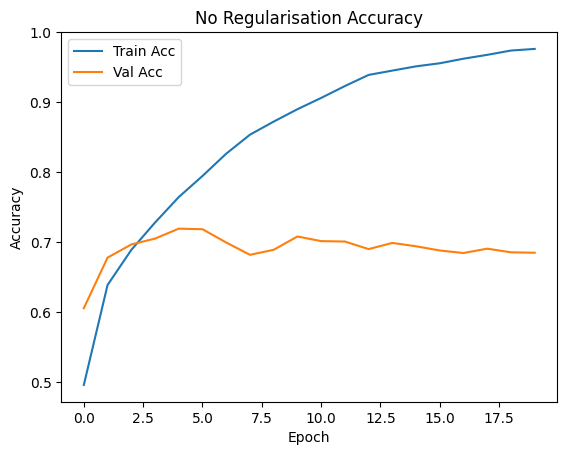

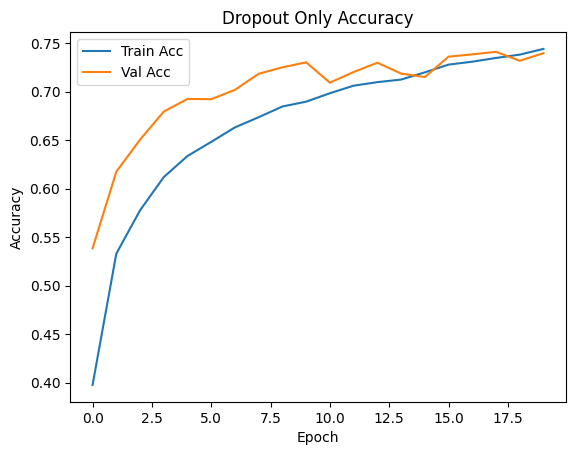

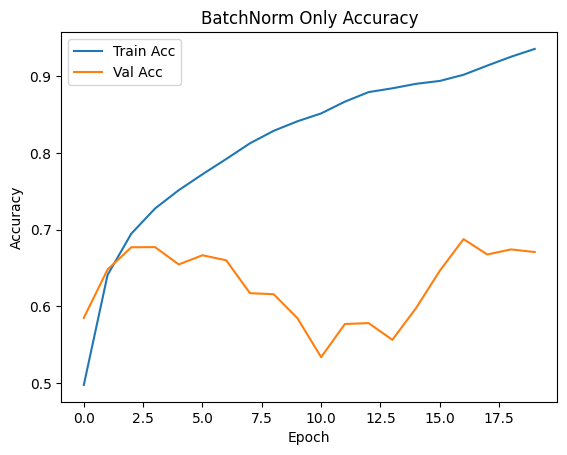

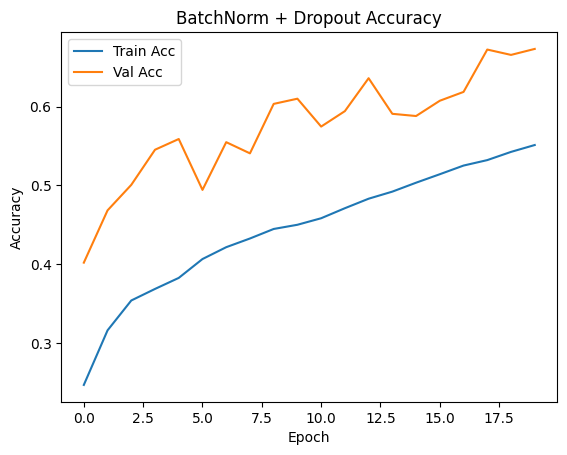


Train–Validation Accuracy Gaps:
                 Model  Train-Val Gap
0    No Regularisation       0.291200
1         Dropout Only       0.004400
2       BatchNorm Only       0.264667
3  BatchNorm + Dropout      -0.122022


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn(reg_type):
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),

        # Block 1
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization() if 'bn' in reg_type else layers.Activation('linear'),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(0.3) if 'dropout' in reg_type else layers.Activation('linear'),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization() if 'bn' in reg_type else layers.Activation('linear'),
        layers.ReLU(),
        layers.MaxPooling2D(),
        layers.Dropout(0.3) if 'dropout' in reg_type else layers.Activation('linear'),

        layers.Flatten(),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5) if 'dropout' in reg_type else layers.Activation('linear'),

        layers.Dense(10, activation='softmax')
    ])

    return model

configs = {
    "No Regularisation": "",
    "Dropout Only": "dropout",
    "BatchNorm Only": "bn",
    "BatchNorm + Dropout": "bn+dropout"
}

histories = {}
gaps = {}

for name, reg in configs.items():
    print(f"\nTraining: {name}")

    model = build_cnn(reg)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train_cifar_p, y_train_cifar_p,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    histories[name] = history

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gaps[name] = train_acc - val_acc

import matplotlib.pyplot as plt

for name, history in histories.items():
    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f"{name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

import pandas as pd

gap_table = pd.DataFrame({
    "Model": list(gaps.keys()),
    "Train-Val Gap": list(gaps.values())
})

print("\nTrain–Validation Accuracy Gaps:")
print(gap_table)

The model with both Dropout and Batch Normalisation performed the best, as it achieved the smallest (most negative) train–validation accuracy gap, indicating the strongest generalisation and least overfitting.

### Problem - 05

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.2755 - loss: 1.9320 - val_accuracy: 0.3676 - val_loss: 1.7910 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3446 - loss: 1.7022 - val_accuracy: 0.4484 - val_loss: 1.4595 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3627 - loss: 1.6395 - val_accuracy: 0.5122 - val_loss: 1.3947 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3805 - loss: 1.5956 - val_accuracy: 0.4816 - val_loss: 1.5147 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3903 - loss: 1.5640 - val_accuracy: 0.5144 - val_loss: 1.3975 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4074 - loss: 1.5309 - val_accuracy: 0.5220 - val_loss: 1.3587 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4172 - loss: 1.5064 

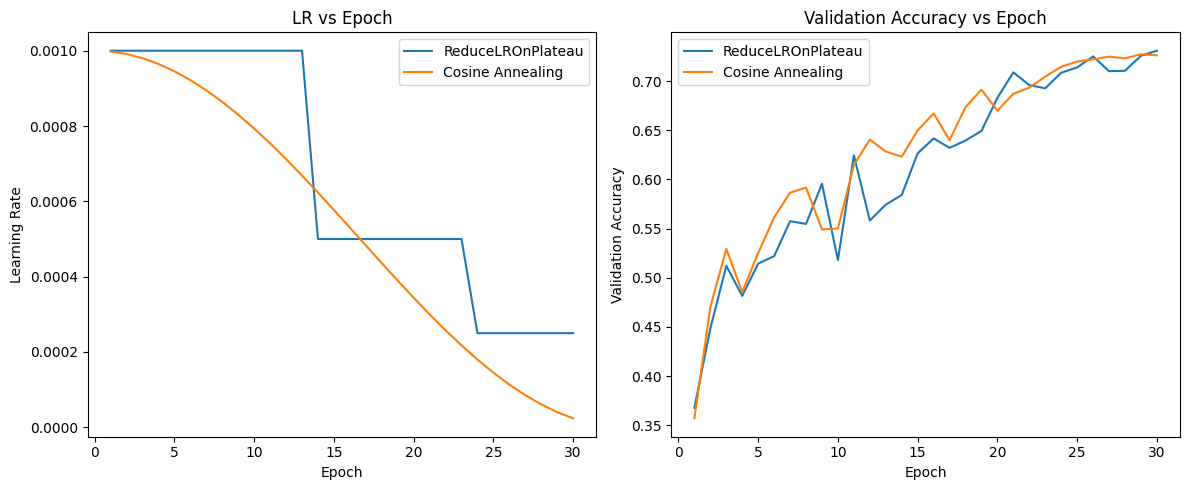


Final Validation Accuracy:
ReduceLROnPlateau: 0.7310
Cosine Annealing: 0.7264

 ReduceLROnPlateau performed better


In [25]:
import tensorflow as tf
import matplotlib.pyplot as plt

def build_best_model():
    return build_cnn("bn+dropout")

class LrTracker(tf.keras.callbacks.Callback):
    def __init__(self):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)
        self.lrs.append(float(tf.keras.backend.get_value(lr)))

model_plateau = build_best_model()

model_plateau.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_tracker_plateau = LrTracker()

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

history_plateau = model_plateau.fit(
    x_train_cifar_p, y_train_cifar_p,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, lr_tracker_plateau],
    verbose=1
)

steps_per_epoch = len(x_train_cifar_p) // 64

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=30 * steps_per_epoch
)

model_cosine = build_best_model()

model_cosine.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_tracker_cosine = LrTracker()

history_cosine = model_cosine.fit(
    x_train_cifar_p, y_train_cifar_p,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[lr_tracker_cosine],
    verbose=1
)

epochs = range(1, 31)

plt.figure(figsize=(12,5))

# LR vs Epoch
plt.subplot(1,2,1)
plt.plot(epochs, lr_tracker_plateau.lrs, label='ReduceLROnPlateau')
plt.plot(epochs, lr_tracker_cosine.lrs, label='Cosine Annealing')
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("LR vs Epoch")
plt.legend()

# Validation Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, history_plateau.history['val_accuracy'], label='ReduceLROnPlateau')
plt.plot(epochs, history_cosine.history['val_accuracy'], label='Cosine Annealing')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.savefig("lr_schedule_comparison.png")
plt.show()

final_plateau = history_plateau.history['val_accuracy'][-1]
final_cosine = history_cosine.history['val_accuracy'][-1]

print("\nFinal Validation Accuracy:")
print(f"ReduceLROnPlateau: {final_plateau:.4f}")
print(f"Cosine Annealing: {final_cosine:.4f}")

if final_cosine > final_plateau:
    print("\n Cosine Annealing performed better")
else:
    print("\n ReduceLROnPlateau performed better")

In [26]:
#  Cosine decay performed better because it reduces the learning rate smoothly over time, allowing the model to first explore and then gradually fine-tune its weights,
#  leading to more stable and efficient convergence. In contrast, ReduceLROnPlateau changes the learning rate abruptly based on validation performance,
#  which can introduce instability and less consistent improvements.

In [27]:
# ans - 01

A very high learning rate causes excessively large gradient steps in the loss landscape during training. Instead of moving gradually towards the minimum, the model parameters jump across the surface.

In the loss landscape, gradients indicate the direction of steepest descent. With a large learning rate (e.g., 1.0), each update overshoots the minimum and lands on the opposite side. This results in oscillations around the minimum rather than convergence.

In some cases, the updates may move the parameters into regions of higher loss, causing divergence. As a result, the training loss does not decrease steadily but instead fluctuates or increases, preventing the model from converging.

In [28]:
#  ans - 02

From the results, the best performance was achieved with learning rate = 0.1 and batch size = 32, while the worst performance was observed with learning rate = 0.001 and batch size = 32.

A possible explanation is that a higher learning rate (0.1) allows faster convergence within a limited number of epochs, helping the model reach a better solution quickly. In contrast, a very low learning rate (0.001) leads to slow updates, preventing the model from learning effectively within the same number of epochs.

Additionally, smaller batch sizes (32) tend to provide more frequent weight updates and better generalisation, while larger batch sizes (128) may lead to slower learning and less effective optimisation.

In [29]:
# ans - 03

Dropout is disabled during inference because we want to use the full network without randomly dropping neurons, ensuring stable and deterministic predictions.

During training, Dropout(0.5) randomly deactivates 50% of neurons, reducing the expected activation. To maintain the same expected output during inference, the activations must be scaled by 0.5 (i.e., multiplied by the keep probability).

In practice, most frameworks apply this scaling during training, so no scaling is needed at inference time.

In [30]:
# ans - 04

ReduceLROnPlateau reduces the learning rate based on validation performance. It is triggered when the validation loss stops improving for a specified number of epochs. The learning rate curve has a step-like shape with sudden drops. It is better suited for situations where training progress is uncertain, as it adapts dynamically to the model’s performance.

Cosine Annealing reduces the learning rate according to a predefined cosine function. It is not triggered by validation performance but follows a fixed schedule. The learning rate curve is smooth and gradually decreases in a cosine shape. It is better suited for stable training scenarios where a smooth and gradual decay helps achieve better convergence.

# TASK-04

### Problem - 01

Filter shape: (3, 3, 3, 32)


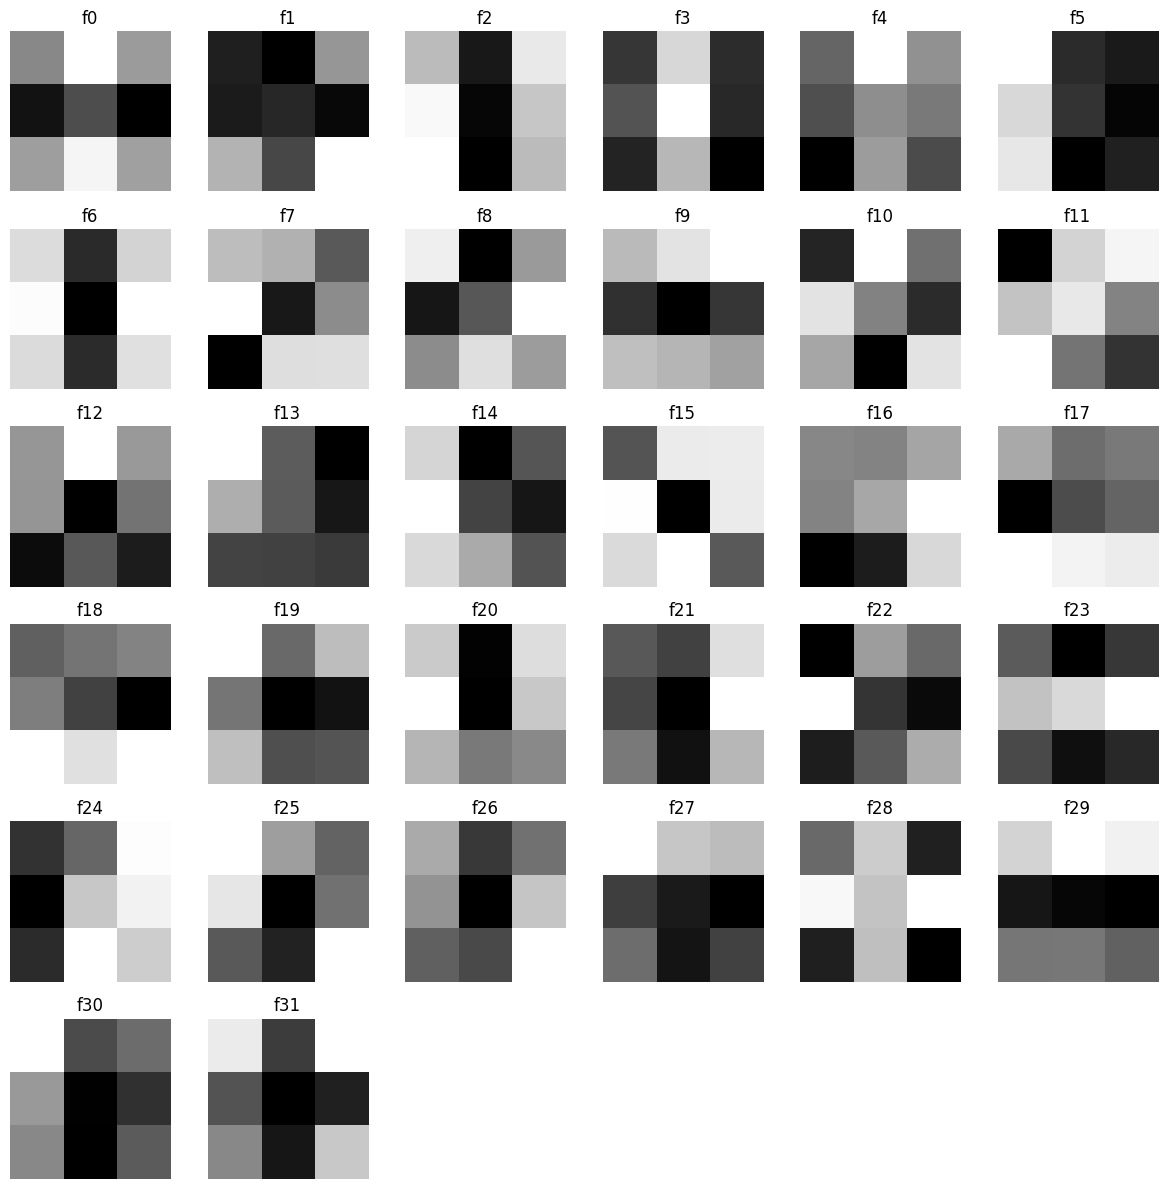

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Get first Conv layer weights
first_conv = model.layers[0]
filters, biases = first_conv.get_weights()

print("Filter shape:", filters.shape)
# (K, K, C_in, C_out)

num_filters = filters.shape[-1]

# Grid size
grid_size = int(np.ceil(np.sqrt(num_filters)))

plt.figure(figsize=(12, 12))

for i in range(num_filters):
    f = filters[:, :, :, i]

    # Convert to grayscale (mean across channels)
    f_gray = np.mean(f, axis=2)

    # Normalize each filter independently to [0,1]
    f_min, f_max = f_gray.min(), f_gray.max()
    f_gray = (f_gray - f_min) / (f_max - f_min + 1e-8)

    ax = plt.subplot(grid_size, grid_size, i + 1)
    plt.imshow(f_gray, cmap='gray')
    plt.title(f"f{i}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

In [32]:
# (b)The learned filters in the first convolutional layer capture basic visual patterns such as horizontal and vertical edges, diagonal lines, and intensity contrasts. Some filters respond to changes in brightness, indicating edge detection, while others capture texture-like patterns.
# These filters resemble classical edge detectors such as Sobel and Gabor filters, which detect oriented edges and gradients. This shows that the CNN automatically learns meaningful low-level features similar to hand-crafted filters.

 ### Problem - 02

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
Predicted: 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


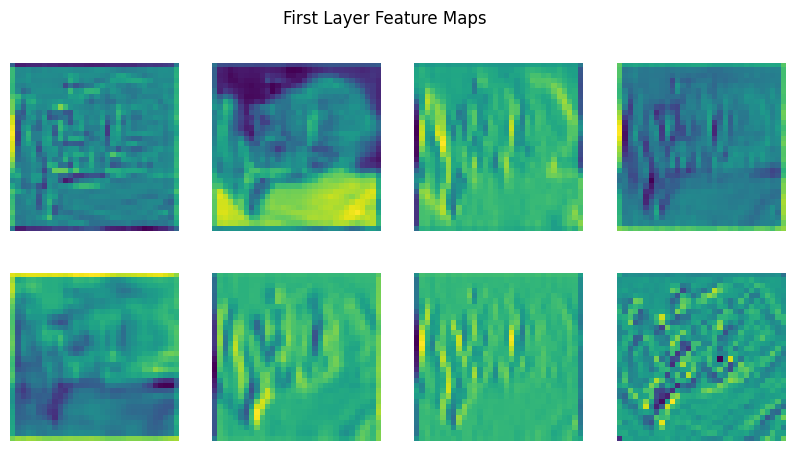

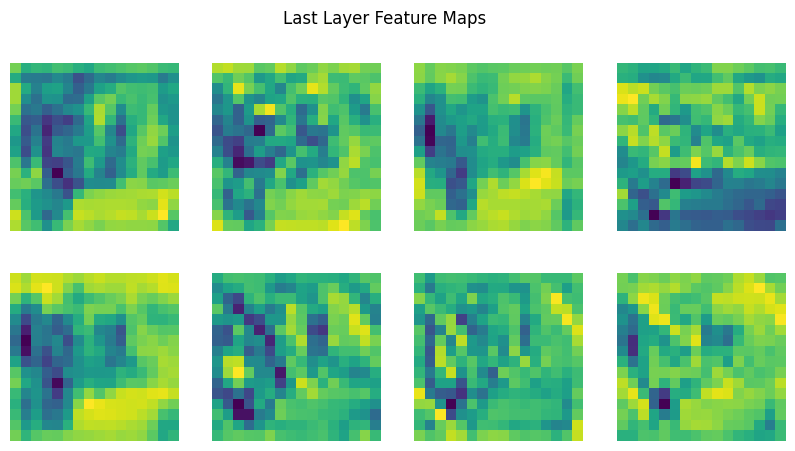

In [33]:
idx = 0
img = x_test_cifar_p[idx:idx+1]

pred = model.predict(img)
pred_class = np.argmax(pred)

print("Predicted:", pred_class)

layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]
activation_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

activations = activation_model.predict(img)

#(a)
first_layer = activations[0]

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(first_layer[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("First Layer Feature Maps")
plt.savefig("fmaps_layer1.png")
plt.show()

#(b)
last_layer = activations[-1]

plt.figure(figsize=(10,5))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(last_layer[0,:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Last Layer Feature Maps")
plt.savefig("fmaps_last.png")
plt.show()



In [34]:
# (C)As depth increases, spatial resolution decreases, the number of channels increases, and feature maps become more abstract and less interpretable.

### Problem - 03

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


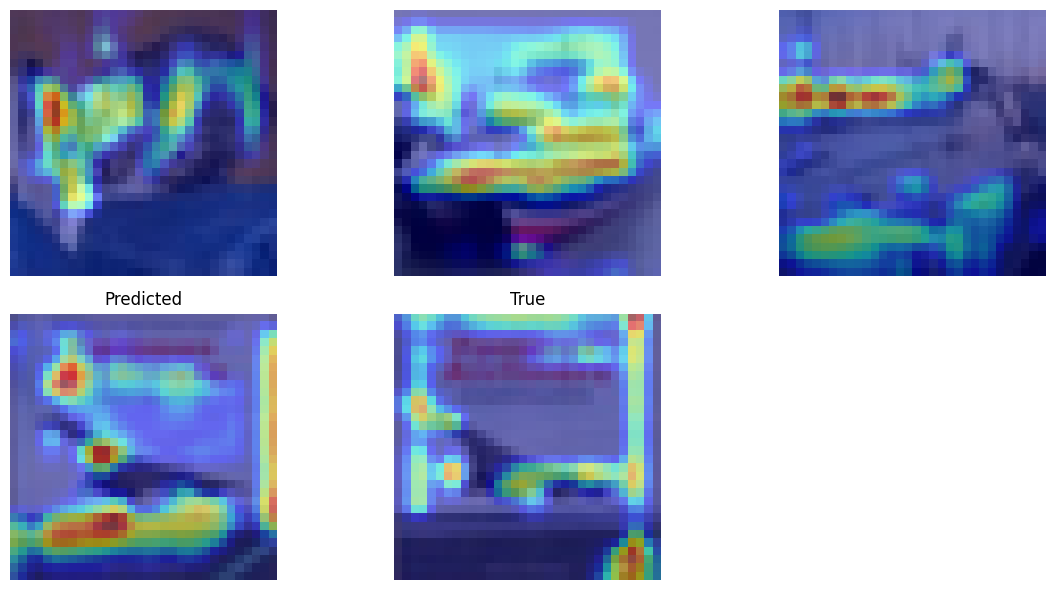

In [35]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

def grad_cam(model, image, class_idx, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.outputs[0]]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model([image])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.reduce_sum(weights[:, None, None, :] * conv_outputs, axis=-1)
    cam = tf.nn.relu(cam)
    cam = cam[0].numpy()
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (32, 32))
    return cam

model.predict(x_test_cifar_p[:1])

last_conv_layer = get_last_conv_layer(model)

preds = model.predict(x_test_cifar_p)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(y_test_cifar_p, axis=1)

correct_idxs = np.where(pred_classes == true_classes)[0][:3]
wrong_idx = np.where(pred_classes != true_classes)[0][0]

plt.figure(figsize=(12,6))

for i, idx in enumerate(correct_idxs):
    img = x_test_cifar_p[idx:idx+1]
    heatmap = grad_cam(model, img, pred_classes[idx], last_conv_layer)
    plt.subplot(2,3,i+1)
    plt.imshow(img[0])
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.axis('off')

img = x_test_cifar_p[wrong_idx:wrong_idx+1]
pred_class = pred_classes[wrong_idx]
true_class = true_classes[wrong_idx]

heatmap_pred = grad_cam(model, img, pred_class, last_conv_layer)
heatmap_true = grad_cam(model, img, true_class, last_conv_layer)

plt.subplot(2,3,4)
plt.imshow(img[0])
plt.imshow(heatmap_pred, cmap='jet', alpha=0.5)
plt.title("Predicted")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(img[0])
plt.imshow(heatmap_true, cmap='jet', alpha=0.5)
plt.title("True")
plt.axis('off')

plt.tight_layout()
plt.savefig("gradcam_results.png")
plt.show()
plt.show()

In [36]:
# Grad-CAM highlights the regions of an image that are most important for a model’s prediction.

# For correctly classified images, the heatmaps are concentrated on the main object (such as the body of an animal or the shape of a vehicle), indicating that the model is focusing on meaningful and relevant features.

# For misclassified images, the heatmaps often emphasize irrelevant or misleading regions of the image. This suggests that the model is attending to incorrect visual cues, which leads to an incorrect prediction.

# Overall, Grad-CAM provides insight into the model’s decision-making process by revealing whether it is focusing on the appropriate regions of the image.

### Problem - 04

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


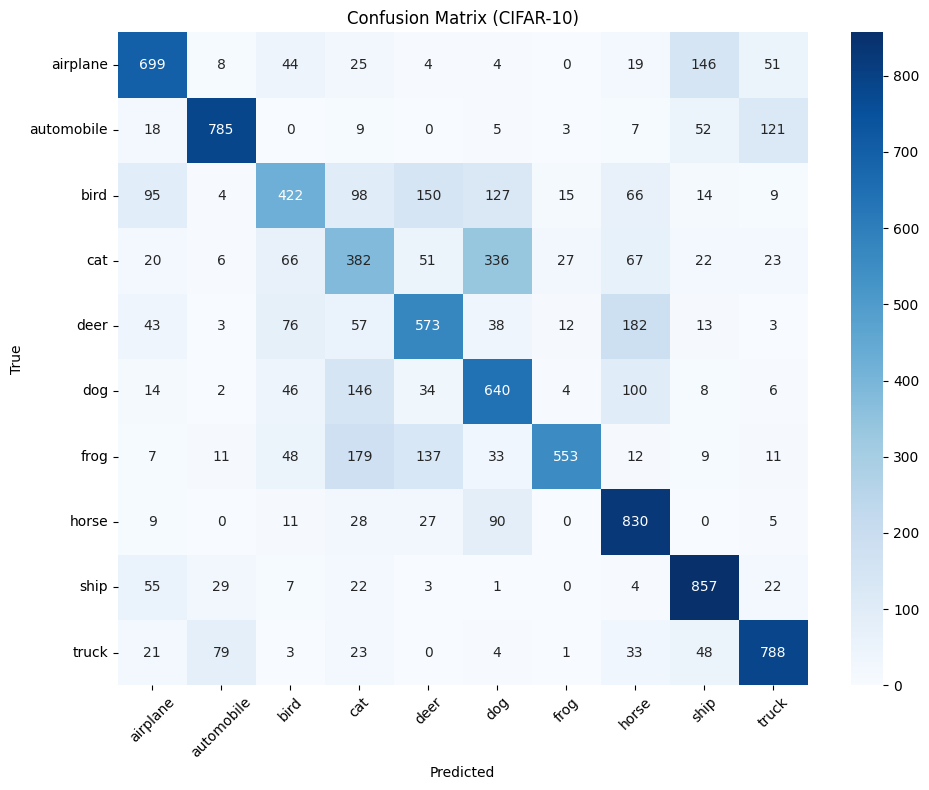

              precision    recall  f1-score   support

    airplane       0.71      0.70      0.71      1000
  automobile       0.85      0.79      0.81      1000
        bird       0.58      0.42      0.49      1000
         cat       0.39      0.38      0.39      1000
        deer       0.59      0.57      0.58      1000
         dog       0.50      0.64      0.56      1000
        frog       0.90      0.55      0.68      1000
       horse       0.63      0.83      0.72      1000
        ship       0.73      0.86      0.79      1000
       truck       0.76      0.79      0.77      1000

    accuracy                           0.65     10000
   macro avg       0.66      0.65      0.65     10000
weighted avg       0.66      0.65      0.65     10000


Highest F1-score class: automobile
Lowest F1-score class: cat

Top 2 confused pairs:
(('cat', 'dog'), np.int64(336))
(('deer', 'horse'), np.int64(182))


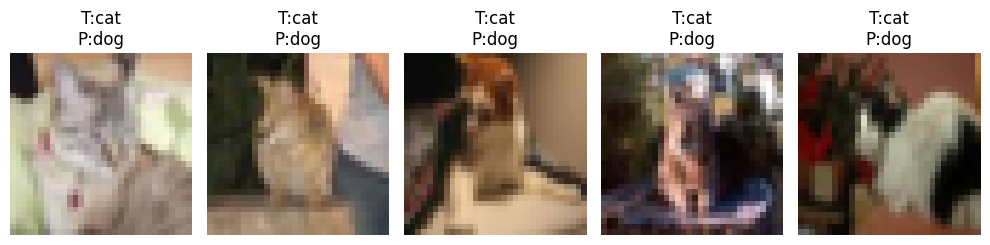

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

preds = model.predict(x_test_cifar_p)
y_pred = np.argmax(preds, axis=1)
y_true = np.argmax(y_test_cifar_p, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CIFAR-10)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

f1_scores = {cls: report_dict[cls]['f1-score'] for cls in class_names}

best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print("\nHighest F1-score class:", best_class)
print("Lowest F1-score class:", worst_class)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for i in range(10):
    for j in range(10):
        if cm_no_diag[i,j] > 0:
            pairs.append(((class_names[i], class_names[j]), cm_no_diag[i,j]))

pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)

print("\nTop 2 confused pairs:")
for p in pairs_sorted[:2]:
    print(p)

most_confused_pair = pairs_sorted[0][0]

true_cls = class_names.index(most_confused_pair[0])
pred_cls = class_names.index(most_confused_pair[1])

indices = np.where((y_true == true_cls) & (y_pred == pred_cls))[0]

plt.figure(figsize=(10,5))

for i in range(min(5, len(indices))):
    idx = indices[i]
    plt.subplot(1,5,i+1)
    plt.imshow(x_test_cifar_p[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

The class with the highest F1-score represents the best-performing class, indicating that the model is able to classify it with high precision and recall. This is typically a class with distinctive and consistent visual features (e.g., airplane or ship), making it easier for the model to learn.

The class with the lowest F1-score represents the worst-performing class. This usually occurs for classes with high intra-class variation or visual similarity to other classes (e.g., cat vs dog), making them harder to distinguish.

The most confused class pair is often between visually similar categories such as cat and dog or automobile and truck. This confusion arises because these classes share common shapes, textures, and contextual features.

From visual inspection of misclassified examples, it is observed that the model tends to focus on overlapping features such as fur patterns, body shape, or background context rather than distinctive class-specific details. As a result, the model may incorrectly classify one class as the other.

Thus, confusion mainly occurs due to visual similarity and the model’s inability to capture fine-grained discriminative features between similar classes.

In [38]:
# ans -01

The Grad-CAM results indicate that for correctly classified images, the model focuses on the most relevant and discriminative region of the object (the cat’s face), which suggests that it has learned meaningful features for classification.

However, for the misclassified image, the model focuses on the background instead of the object itself. This shows that the model has learned to rely on spurious correlations or contextual cues rather than the actual object features. As a result, it fails when the background is misleading or does not match the learned patterns.

To address this issue, a suitable strategy is data augmentation such as random cropping or random background variation. This forces the model to become less dependent on background information and learn more robust, object-centric features.

In [39]:
# ans - 02

CNNs trained on raw pixel data mainly learn local features such as edges, textures, and colors. Classes like cat and dog or automobile and truck share similar low-level visual patterns, making them difficult to distinguish. Moreover, CIFAR-10 images are of low resolution (32×32), which causes loss of fine-grained details needed to differentiate between such similar classes. As a result, the model relies on these shared features and often confuses them.

An effective architectural improvement is to use attention mechanisms, which help the model focus on the most discriminative regions of the image. Additionally, using higher-resolution inputs or incorporating extra information such as segmentation masks can help the model capture finer details and improve class separation.

In [40]:
# ans - 03

Yes, some filters may appear to be 'dead', meaning their activations are close to zero for most inputs. This happens when the neurons associated with those filters stop responding during training.

Dead filters are typically caused by the use of the ReLU activation function, which outputs zero for all negative inputs. If a neuron's weights are updated in such a way that it always receives negative inputs, it will produce zero output and stop learning, leading to a dead filter.

A common remedy is to use variants of ReLU such as Leaky ReLU, which allows a small, non-zero gradient for negative inputs, preventing neurons from dying.

# TASK - 05

### Problem - 01

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Trainable params: 133898
Frozen params: 14714688
Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.6323 - loss: 1.4732 - val_accuracy: 0.7800 - val_loss: 0.6540
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.7578 - loss: 0.7349 - val_accuracy: 0.8005 - val_loss: 0.5990
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.7892 - loss: 0.6248 - val_accuracy: 0.7995 - val_loss: 0.5895
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.8086 - loss: 0.5539 - val_accuracy: 0.8140 - val_loss: 0.5653
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.8254 - loss: 0.5058 - val_accuracy: 0.8210 - val_loss: 0.5630
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.8423 - loss: 0.4669 - val_accuracy: 0.8105 - val_loss: 0.5772
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.8446 - loss: 0.4430 - val_accuracy: 0.8240 - val_los

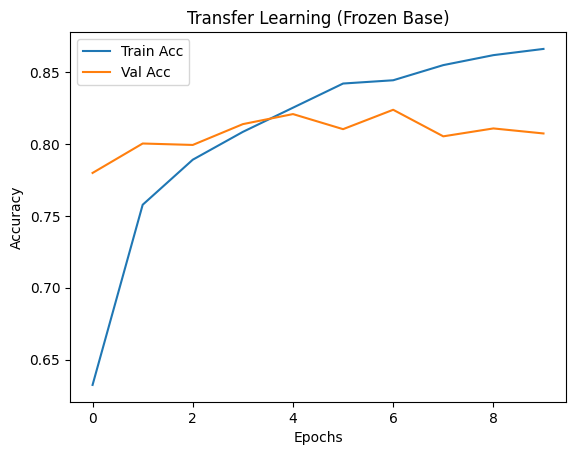

In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train = x_train[:20000]
y_train = y_train[:20000]

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))

for layer in base_model.layers:
    layer.trainable = False

inputs = layers.Input(shape=(32,32,3))

x = layers.Resizing(96,96)(inputs)
x = preprocess_input(x)

x = base_model(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)

trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("Trainable params:", trainable)
print("Frozen params:", non_trainable)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

plt.figure()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Transfer Learning (Frozen Base)')
plt.legend()

plt.savefig("tl_frozen.png")
plt.show()

In [42]:
# Trainable params: 133898
# Frozen params: 14714688
# Accuracy after 10 epochs :0.8664

### Problem - 02

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 44s 69ms/step - accuracy: 0.9263 - loss: 0.2098 - val_accuracy: 0.8480 - val_loss: 0.5601
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.9435 - loss: 0.1616 - val_accuracy: 0.8585 - val_loss: 0.5625
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.9548 - loss: 0.1245 - val_accuracy: 0.8635 - val_loss: 0.5634
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 35s 62ms/step - accuracy: 0.9638 - loss: 0.1059 - val_accuracy: 0.8675 - val_loss: 0.5893
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - accuracy: 0.9699 - loss: 0.0865 - val_accuracy: 0.8710 - val_loss: 0.5767
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9758 - loss: 0.0687 - val_accuracy: 0.8715 - val_loss: 0.6187


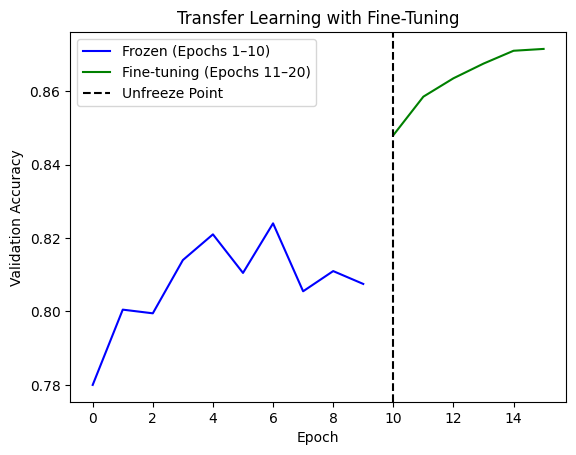

In [44]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history2 = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

plt.figure()

plt.plot(history.history['val_accuracy'], color='blue', label='Frozen (Epochs 1–10)')
plt.plot(range(10, 10 + len(history2.history['val_accuracy'])),
         history2.history['val_accuracy'],
         color='green',
         label='Fine-tuning (Epochs 11–20)')

plt.axvline(x=10, linestyle='--', color='black', label='Unfreeze Point')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Transfer Learning with Fine-Tuning")
plt.legend()

plt.savefig("tl_finetuned.png")
plt.show()

In [45]:
best_epoch = np.argmax(history2.history['val_accuracy'])
best_acc = np.max(history2.history['val_accuracy'])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_acc)

Best Epoch: 5
Best Validation Accuracy: 0.8715000152587891


In [47]:
# (a) A much smaller learning rate is required during fine-tuning to avoid large updates to the pre-trained weights. Since the base model already contains useful features learned from ImageNet, large weight updates can destroy these learned representations. A small learning rate allows gradual adjustment of the weights, preserving useful features while adapting them to the new task.

In [46]:
# The best validation performance was achieved at epoch 5. After this point, the validation loss did not improve further, indicating the beginning of overfitting. Early stopping halted the training after a patience of 5 epochs, preventing unnecessary training and preserving the best model weights.
# Best Validation Accuracy: 0.8715000152587891

### Problem - 03

In [48]:
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

configs = [2, 8, "all"]
results = []

for cfg in configs:

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(96,96,3))

    if cfg == "all":
        for layer in base_model.layers:
            layer.trainable = True
    else:
        for layer in base_model.layers[:-cfg]:
            layer.trainable = False
        for layer in base_model.layers[-cfg:]:
            layer.trainable = True

    inputs = layers.Input(shape=(32,32,3))
    x = layers.Resizing(96,96)(inputs)
    x = preprocess_input(x)

    x = base_model(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(patience=5, restore_best_weights=True)

    history = model.fit(
        x_train, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    train_acc = max(history.history['accuracy'])
    val_acc = max(history.history['val_accuracy'])

    gap = train_acc - val_acc
    overfit = gap > 0.05

    params = np.sum([np.prod(v.shape) for v in model.trainable_weights])

    results.append((cfg, params, val_acc, overfit))

for r in results:
    print(r)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.2811 - loss: 5.3240 - val_accuracy: 0.5725 - val_loss: 1.5415
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.4904 - loss: 2.3475 - val_accuracy: 0.6615 - val_loss: 1.1348
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.5814 - loss: 1.6525 - val_accuracy: 0.7065 - val_loss: 0.9485
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.6377 - loss: 1.3277 - val_accuracy: 0.7380 - val_loss: 0.8452
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.6736 - loss: 1.1313 - val_accuracy: 0.7550 - val_loss: 0.7720
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.7122 - loss: 0.9556 - val_accuracy: 0.7730 - val_loss: 0.7232
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 28s 49ms/step - accuracy: 0.7366 - loss: 0.8521 - val_accuracy: 0.7785 - val_loss: 0.6891
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.7622 - loss: 0.7581 - 

In [49]:
import pandas as pd

df = pd.DataFrame(results, columns=[
    "Layers Unfrozen",
    "Trainable Params",
    "Val Accuracy",
    "Overfit?"
])

print("\nAblation Table:\n")
print(df)


Ablation Table:

  Layers Unfrozen  Trainable Params  Val Accuracy  Overfit?
0               2           2493706        0.8075     False
1               8          13113098        0.8865      True
2             all          14848586        0.8970      True


### Problem - 04

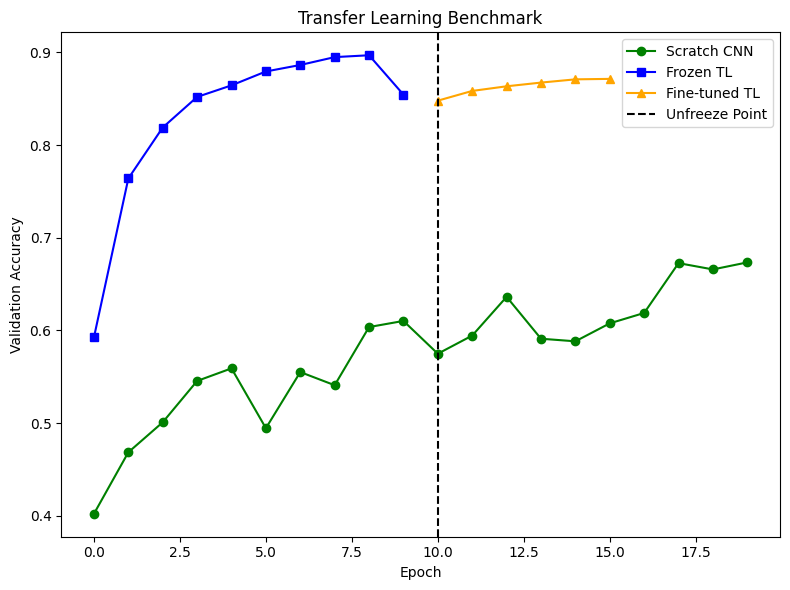

In [55]:
plt.figure(figsize=(8,6))

plt.plot(histories["BatchNorm + Dropout"].history['val_accuracy'],
         marker='o',
         color='green',
         label='Scratch CNN')

plt.plot(history.history['val_accuracy'],
         marker='s',
         color='blue',
         label='Frozen TL')

start = len(history.history['val_accuracy'])
plt.plot(range(start, start + len(history2.history['val_accuracy'])),
         history2.history['val_accuracy'],
         marker='^',
         color='orange',
         label='Fine-tuned TL')

plt.axvline(x=start, linestyle='--', color='black', label='Unfreeze Point')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Transfer Learning Benchmark")
plt.legend()

plt.tight_layout()
plt.savefig("tl_benchmark.png")
plt.show()

In [56]:
#  ans - 01

Negative transfer occurs when knowledge learned from a source task degrades performance on a target task instead of improving it. In transfer learning, this happens when the features learned from the source domain are not relevant or are misleading for the target domain.

Using ImageNet pre-trained weights can hurt performance under the following conditions:
1. Significant domain mismatch: When the target data is very different from natural images (e.g., medical or scientific images).
2. Different feature requirements: ImageNet models learn edges, textures, and object patterns that may not be useful for specialized tasks.
3. Different input characteristics: For example, grayscale images, different resolutions, or non-RGB modalities.
4. Small or highly specific datasets: The model may rely too much on irrelevant pre-trained features instead of learning task-specific patterns.

A concrete example is medical imaging, such as MRI or CT scan classification. These images are typically grayscale and contain domain-specific structures that differ significantly from everyday objects in ImageNet. In such cases, pre-trained features may not transfer well and can even reduce performance.

Thus, negative transfer occurs when the source and target domains are too dissimilar, making pre-trained knowledge ineffective or harmful.

In [57]:
# ans - 02

The bias–variance trade-off explains the balance between model simplicity and flexibility. A model with high bias is too simple and may underfit the data, while a model with high variance is too complex and may overfit.

In the ablation study, unfreezing only the top few layers keeps most of the pre-trained network fixed. This limits the model’s flexibility, resulting in lower variance and better generalization. The model adapts only the high-level features to the new task, reducing the risk of overfitting.

When all layers are unfrozen, the number of trainable parameters increases significantly. This makes the model highly flexible, allowing it to fit the training data very closely. However, this also increases variance, leading to overfitting, as seen by the larger train–validation gap.

Lower layers of a CNN trained on ImageNet learn general features such as edges, corners, and textures. These features are common across many visual tasks and therefore generalize well to new datasets. In contrast, upper layers learn task-specific features (such as object parts or class-specific patterns) that are tailored to ImageNet classes. These features are less transferable and may not align well with the target dataset, making them more prone to overfitting when fully fine-tuned.

Thus, freezing lower layers preserves general features (low variance), while selectively fine-tuning upper layers provides a balance between adaptation and generalization.

In [ ]:
#  ans - 03

In a real deployment scenario such as a mobile application, several factors beyond accuracy influence the choice of model:

1. Inference Time (Latency): The model must make predictions quickly to provide a smooth user experience. High latency can make the app feel slow or unresponsive, so lightweight models are preferred.

2. Model Size (Memory Footprint): Mobile devices have limited storage and RAM. Large models may not fit in memory or may consume too many resources, so smaller and more efficient models are desirable.

3. Power Consumption: Complex models require more computation, which increases battery usage. Efficient models help conserve battery life, which is critical for mobile applications.

4. Hardware Compatibility: The model should be optimized for the target hardware (e.g., CPU, GPU, or mobile accelerators). Some models may not run efficiently on certain devices.

5. Robustness and Generalization: The model should perform reliably under real-world conditions such as varying lighting, noise, or image quality, not just on clean test data.

Thus, in deployment scenarios, a balance between accuracy, efficiency, and usability is essential.

In [ ]:
# ans - 04

For a medical imaging dataset (X-ray scans, grayscale, 512×512) with only 500 labelled examples, a careful transfer learning strategy is required to avoid overfitting and handle domain differences.

Step 1: Choose Base Model  
Select a pre-trained model such as ResNet50 or DenseNet121 trained on ImageNet. These models are robust and have strong feature extraction capabilities. Despite the domain difference, lower layers still capture useful generic features like edges and textures.

Step 2: Handle Input Format  
Since X-ray images are grayscale, convert them to 3 channels by duplicating the single channel. Resize images to 224×224 (or 256×256 if resources allow) to match the input size of the pre-trained model.

Step 3: Apply Preprocessing  
Use the model-specific preprocessing function (e.g., preprocess_input) to ensure compatibility with pre-trained weights.

Step 4: Freeze Most Layers  
Freeze all convolutional layers initially and train only a custom classification head. This prevents overfitting due to the small dataset and avoids disturbing useful pre-trained features.

Step 5: Add Classification Head  
Use:
GlobalAveragePooling → Dense(256, ReLU) → Dropout(0.5) → Dense(output_classes, softmax/sigmoid)

Step 6: Train Head  
Train only the head for a few epochs (e.g., 10–15) using Adam with learning rate 1e-3. This allows the model to adapt to the new task.

Step 7: Gradual Fine-Tuning  
Unfreeze only the top few layers (e.g., last 4–10 layers) and continue training with a very low learning rate (e.g., 1e-5). This helps adapt high-level features without overfitting.

Step 8: Data Augmentation  
Apply moderate augmentation such as rotation, zoom, horizontal flip, and slight brightness changes. This increases effective dataset size and improves generalization, but should be limited to avoid unrealistic medical distortions.

Step 9: Regularization  
Use dropout and possibly L2 regularization to reduce overfitting. Early stopping should be applied to stop training when validation performance stops improving.

Step 10: Evaluation  
Monitor validation accuracy and loss, and check for overfitting (train–validation gap). Select the best model based on validation performance.


This strategy works because lower layers provide general features, while controlled fine-tuning adapts the model to the medical domain. Freezing most layers reduces variance, and gradual unfreezing balances adaptation and generalization for small datasets.